# Step 1: GEE接続確認 + 1圃場のNDVI取得

**目的:** GEEに接続できるかを確認し、1つの圃場（field_id=1）のNDVI時系列を取得します。

**処理の流れ:**
1. GEE認証・初期化
2. 1圃場の座標を指定
3. Sentinel-2 + Cloud Score+ でNDVI時系列を取得
4. 結果をDataFrameで表示・簡単なプロット


## Cell 1: 認証

**初回のみ** `ee.Authenticate()` を実行します。
ブラウザが開くのでGEEに登録したGoogleアカウントでログインしてください。
2回目以降は不要です。


In [3]:
import ee

# 初回のみ実行（ブラウザが開きます）
ee.Authenticate()


True

In [4]:
# GCP プロジェクト ID を設定して初期化
# 自分のGCPプロジェクトIDに書き換えてください
GCP_PROJECT = 'ndvi-505105'  # <- ここを変更

ee.Initialize(project=GCP_PROJECT)
print('GEE接続成功！')
print(f'  使用プロジェクト: {GCP_PROJECT}')


GEE接続成功！
  使用プロジェクト: ndvi-505105


## Cell 2: 圃場座標の読み込み


In [5]:
import sqlite3
import pandas as pd

FIELD_DB = '../../data/processed/FieldData_fieldid.db'

conn = sqlite3.connect(FIELD_DB)
fields_df = pd.read_sql("""
    SELECT field_id, year, lat, lon, yield
    FROM Questionaire
    WHERE lat IS NOT NULL AND lon IS NOT NULL AND yield IS NOT NULL
    ORDER BY field_id, year
""", conn)
conn.close()

fields_df['field_id'] = fields_df['field_id'].astype(int)
fields_df['year']     = fields_df['year'].astype(int)
fields_df['lat']      = pd.to_numeric(fields_df['lat'], errors='coerce')
fields_df['lon']      = pd.to_numeric(fields_df['lon'], errors='coerce')

print(f'圃場数: {fields_df["field_id"].nunique()} 圃場')
print(f'対象年: {sorted(fields_df["year"].unique().tolist())}')
fields_df.head()


圃場数: 603 圃場
対象年: [2015, 2016, 2017, 2018]


,field_id,year,lat,lon,yield
0,1,2016,43.117144,141.720880,362.581300
1,2,2016,43.170298,141.721513,307.841668
2,3,2016,43.146282,141.744142,92.679090
3,4,2016,43.297893,141.703895,431.459001
4,5,2016,43.313596,141.699987,272.666353


## Cell 3: NDVI取得関数

**使用するGEEデータセット:**
- `COPERNICUS/S2_SR_HARMONIZED`: Sentinel-2 地表反射率
- `GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED`: AIベース雲評価

**NDVI = (B8 - B4) / (B8 + B4)**


In [11]:
def get_ndvi_timeseries(lat, lon, year, buffer_m=100, verbose=True):
    """
    指定した点座標周辺のSentinel-2 NDVI時系列を取得する。
    雲マスクなし・全シーン取得。

    Args:
        lat      (float): 緯度
        lon      (float): 経度
        year     (int)  : 対象年
        buffer_m (int)  : バッファ半径[m]（デフォルト100m）
        verbose  (bool) : デバッグ情報を表示するか

    Returns:
        pd.DataFrame: date, NDVI, n_pixels 列
    """
    point = ee.Geometry.Point([lon, lat])
    aoi   = point.buffer(buffer_m)

    start_date = f'{year}-06-01'
    end_date   = f'{year}-11-30'

    s2_col = (
        ee.ImageCollection('COPERNICUS/S2_HARMONIZED')  # L1C：雲マスクなし
        .filterDate(start_date, end_date)
        .filterBounds(aoi)
    )

    if verbose:
        n_raw = s2_col.size().getInfo()
        tiles = set(s2_col.aggregate_array('MGRS_TILE').getInfo())
        print(f'  [DEBUG] 総シーン数: {n_raw}  タイル: {tiles}')

    # NDVI バンド追加
    def add_ndvi(img):
        ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')
        return img.addBands(ndvi)

    ndvi_col = s2_col.map(add_ndvi).select('NDVI')

    # 各画像から NDVI 平均・有効ピクセル数を抽出
    def extract_value(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean().combine(
                ee.Reducer.count(), sharedInputs=True
            ),
            geometry=aoi,
            scale=10,
            bestEffort=True,
        )
        return ee.Feature(None, {
            'date':     ee.Date(img.get('system:time_start')).format('YYYY-MM-dd'),
            'NDVI':     stats.get('NDVI_mean'),
            'n_pixels': stats.get('NDVI_count'),
        })

    fc = ndvi_col.map(extract_value).getInfo()

    rows = []
    for feat in fc['features']:
        p = feat['properties']
        rows.append({
            'date':     p.get('date'),
            'NDVI':     p.get('NDVI'),
            'n_pixels': p.get('n_pixels'),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df['date']     = pd.to_datetime(df['date'])
    df['NDVI']     = pd.to_numeric(df['NDVI'],     errors='coerce')
    df['n_pixels'] = pd.to_numeric(df['n_pixels'], errors='coerce')

    if verbose:
        print(f'  [DEBUG] NDVI取得件数: {len(df.dropna(subset=["NDVI"]))}')

    return df.dropna(subset=['NDVI']).sort_values('date').reset_index(drop=True)


## Cell 4: 実行 — field_id=1, year=2017

まず1圃場だけ試します。


In [29]:
TARGET_FIELD_ID = 314
TARGET_YEAR     = 2017

row = fields_df[
    (fields_df['field_id'] == TARGET_FIELD_ID) &
    (fields_df['year']     == TARGET_YEAR)
]

if row.empty:
    print(f'field_id={TARGET_FIELD_ID}, year={TARGET_YEAR} のデータが見つかりません')
else:
    lat = float(row.iloc[0]['lat'])
    lon = float(row.iloc[0]['lon'])
    print(f'対象圃場: field_id={TARGET_FIELD_ID}  year={TARGET_YEAR}')
    print(f'  緯度: {lat:.6f}  経度: {lon:.6f}')
    print(f'  実測収量: {float(row.iloc[0]["yield"]):.1f} kg/10a')
    print()
    print('GEEからNDVI取得中... (数秒~30秒程度かかります)')

    ndvi_df = get_ndvi_timeseries(lat, lon, TARGET_YEAR, buffer_m=30)

    print(f'\n取得完了！  {len(ndvi_df)} 件のデータポイント')
    print(ndvi_df.to_string())


対象圃場: field_id=314  year=2017
  緯度: 36.656556  経度: 140.012306
  実測収量: 379.7 kg/10a

GEEからNDVI取得中... (数秒~30秒程度かかります)
  [DEBUG] 総シーン数: 18  タイル: {'54SVF'}
  [DEBUG] NDVI取得件数: 18

取得完了！  18 件のデータポイント
         date      NDVI  n_pixels
0  2017-06-17  0.246873        41
1  2017-07-07  0.382023        41
2  2017-07-22  0.266037        41
3  2017-07-27 -0.023959        41
4  2017-08-11 -0.026642        41
5  2017-08-16 -0.000061        41
6  2017-08-31  0.093487        41
7  2017-09-05  0.776454        41
8  2017-09-20  0.111583        41
9  2017-09-25  0.379098        41
10 2017-10-10  0.397474        41
11 2017-10-15 -0.011826        41
12 2017-10-30  0.329690        41
13 2017-11-04  0.084134        41
14 2017-11-09  0.278859        41
15 2017-11-19  0.125533        41
16 2017-11-24  0.179983        41
17 2017-11-29  0.145464        41


In [ ]:
# ---- タイル別シーン数を確認するデバッグセル ----
point = ee.Geometry.Point([136.439583, 36.422250])
aoi   = point.buffer(100)

s2_raw = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2018-06-01', '2018-11-30')
    .filterBounds(aoi)
)

print(f'総シーン数: {s2_raw.size().getInfo()}')

# タイルIDと日付の一覧
props = s2_raw.aggregate_array('MGRS_TILE').getInfo()
dates = s2_raw.aggregate_array('system:index').getInfo()
tile_set = set(props)
print(f'含まれるMGRSタイル: {tile_set}')
print(f'撮影日（先頭10件）: {dates[:10]}')


## Cell 5: プロット

NDVI時系列をプロットして、大豆の生育曲線が確認できるか見てみます。
健全な大豆圃場なら7~8月にかけてNDVIが上昇し、9月以降に低下する単峰性の曲線になるはずです。


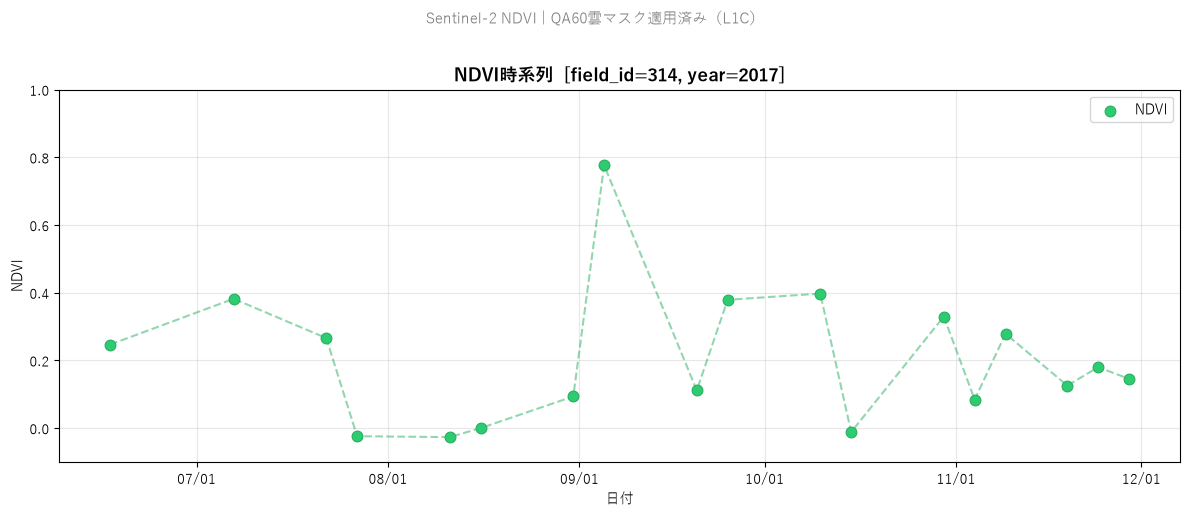

プロット保存: ../../outputs/ndvi_test_field314_2017.png

--- NDVI 基本統計 ---
  観測日数  : 18
  NDVI 最大 : 0.776
  NDVI 平均 : 0.207
  NDVI 最小 : -0.027


In [30]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import os

# ── Windows 日本語フォント設定 ──────────────────────────────
_jp_fonts = ['Yu Gothic', 'MS Gothic', 'Meiryo', 'IPAexGothic', 'Noto Sans CJK JP']
_available = {f.name for f in fm.fontManager.ttflist}
_font = next((f for f in _jp_fonts if f in _available), None)

if _font:
    plt.rcParams['font.family'] = _font
else:
    print('⚠ 日本語フォントが見つかりません。')

plt.rcParams['axes.unicode_minus'] = False
# ─────────────────────────────────────────────────────────────

os.makedirs('../../outputs', exist_ok=True)

if 'ndvi_df' in dir() and not ndvi_df.empty:
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.scatter(ndvi_df['date'], ndvi_df['NDVI'],
               color='#2ecc71', s=60, zorder=3, label='NDVI',
               edgecolors='#27ae60', linewidths=0.8)
    ax.plot(ndvi_df['date'], ndvi_df['NDVI'],
            color='#27ae60', alpha=0.5, lw=1.5, linestyle='--')
    ax.set_title(f'NDVI時系列  [field_id={TARGET_FIELD_ID}, year={TARGET_YEAR}]',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('NDVI')
    ax.set_ylim(-0.1, 1.0)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.set_xlabel('日付')
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.suptitle('Sentinel-2 NDVI | QA60雲マスク適用済み（L1C）',
                 fontsize=11, y=1.02, color='gray')
    plt.tight_layout()

    save_path = f'../../outputs/ndvi_test_field{TARGET_FIELD_ID}_{TARGET_YEAR}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'プロット保存: {save_path}')

    print('\n--- NDVI 基本統計 ---')
    print(f'  観測日数  : {len(ndvi_df)}')
    print(f'  NDVI 最大 : {ndvi_df["NDVI"].max():.3f}')
    print(f'  NDVI 平均 : {ndvi_df["NDVI"].mean():.3f}')
    print(f'  NDVI 最小 : {ndvi_df["NDVI"].min():.3f}')
else:
    print('ndvi_df が空です。Cell 4 を先に実行してください。')


## 次のステップ

このNotebookで確認すること:
- `GEE接続成功！` が表示されるか
- NDVI時系列が取得できるか（観測日数、値の範囲）
- プロットで大豆の生育曲線（夏にピーク）が見えるか

確認できたら次は `02_ndvi_all_fields.ipynb` で全圃場に拡張します。
